In [5]:
from rdkit import Chem
from rdkit.Chem import Draw
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
dock_df = pd.read_csv("../docking/results.csv", names=["id", "smiles", "docking_score"])
similarity_df = pd.read_csv(
    "../screening/similarity_scores.csv", names=["smiles", "similarity"]
)
similarity_df["id"] = similarity_df["smiles"].apply(lambda x: x.split("\t")[1])
similarity_df["smiles"] = similarity_df["smiles"].apply(lambda x: x.split("\t")[0])

df = similarity_df.merge(dock_df, left_on="smiles", right_on="smiles")
df.describe()

,similarity,docking_score
count,58961.000000,58961.000000
mean,0.483023,-8.336309
std,0.091682,0.931897
min,0.404762,-11.909000
25%,0.411765,-9.092000
50%,0.432432,-8.250000
75%,0.567568,-7.608000
max,0.862069,-5.637000


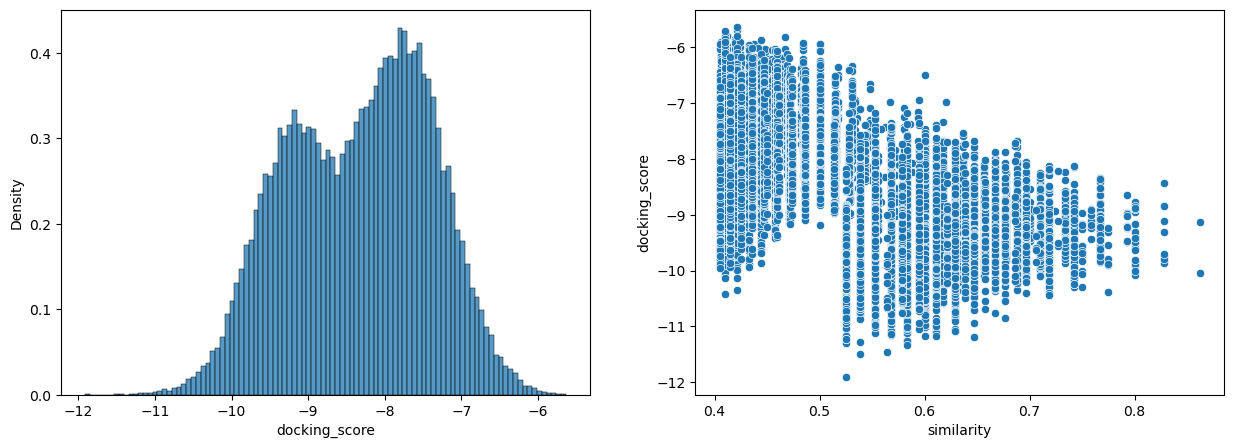

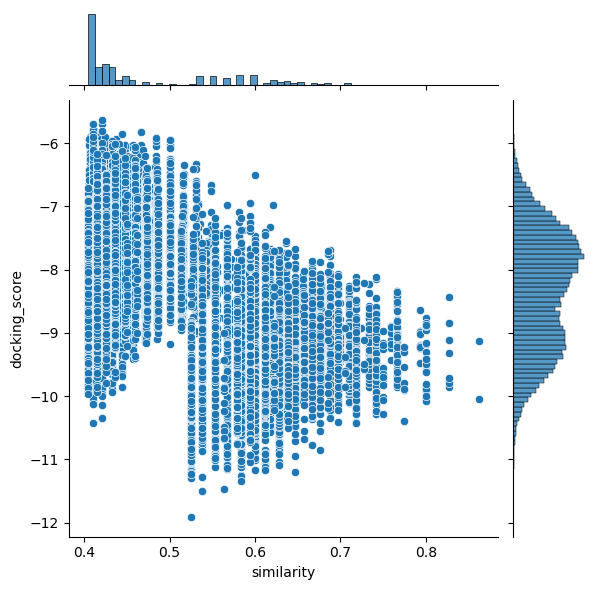

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df, x="docking_score", ax=ax1, stat="density", bins=100)
sns.scatterplot(df, x="similarity", y="docking_score", ax=ax2)
sns.jointplot(df, x="similarity", y="docking_score")

We observe a large improvement in the docking scores as the similarity increases. This is confirmed by the correlation.

In [14]:
df[["similarity", "docking_score"]].corr(method="pearson")

,similarity,docking_score
similarity,1.000000,-0.678938
docking_score,-0.678938,1.000000


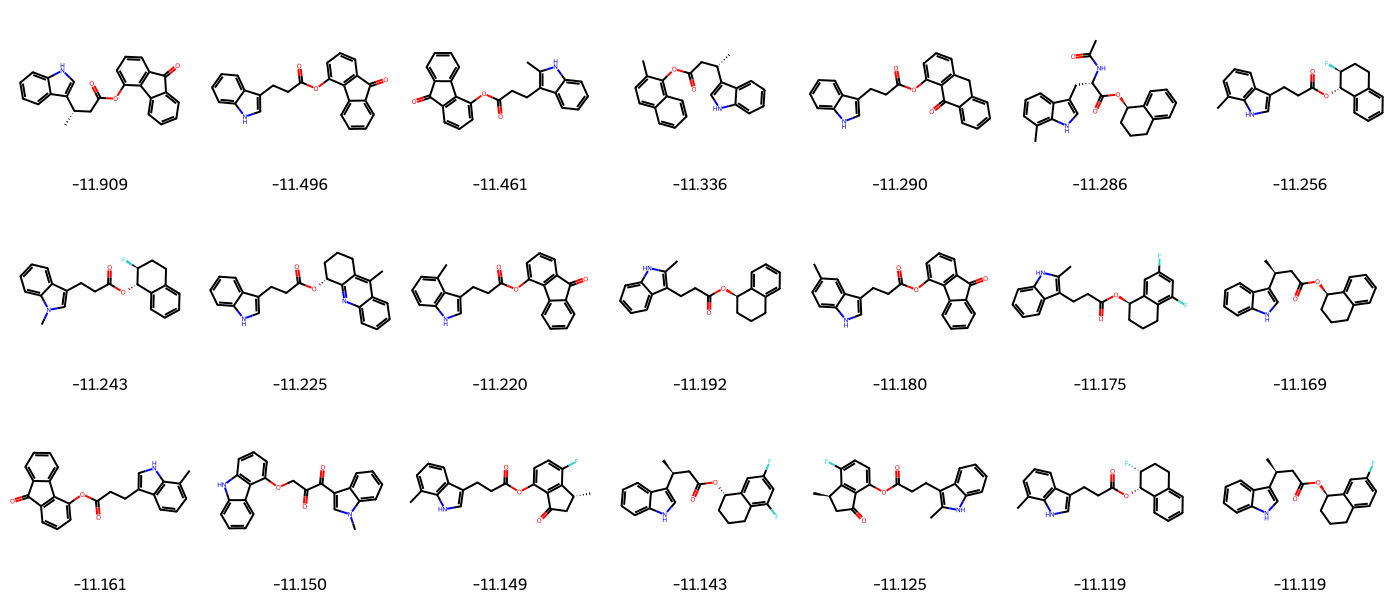

In [12]:
best = df.nsmallest(21, columns="docking_score")
mols = best["smiles"].map(Chem.MolFromSmiles)
Draw.MolsToGridImage(
    mols,
    molsPerRow=7,
    legends=best["docking_score"].apply(lambda x: f"{x:.3f}").tolist(),
)

The docking score histogram has two clear peaks. In the following we will investigate what might be the cause of this.

Looking at the similarity scores and the experimentally valided molecules it seems that the benzene ring with the additional chlor molecule is quite prominent.
We conjecture that molecules with this structure have better docking scores.

In the following we will first fit a gaussian mixture model around the two peaks, assigning each molecule to one of the classes and then compare the assignments to the substructure matches

In [18]:
import numpy as np
from scipy.signal import argrelmax
from sklearn.mixture import GaussianMixture

We first find the two relative maxima and then initialize the GMM with those as means.

In [19]:
counts, bins = np.histogram(dock_df["docking_score"].values, bins=50, density=True)
maxima = argrelmax(counts, order=5)
bins[maxima]

array([-9.27476, -7.76948])

In [20]:
gm = GaussianMixture(n_components=2, means_init=bins[maxima].reshape(-1, 1))
gm.fit(dock_df["docking_score"].values.reshape(-1, 1))

GaussianMixture(means_init=array([[-9.27476],
       [-7.76948]]),
                n_components=2)

Let's visulaize the result.

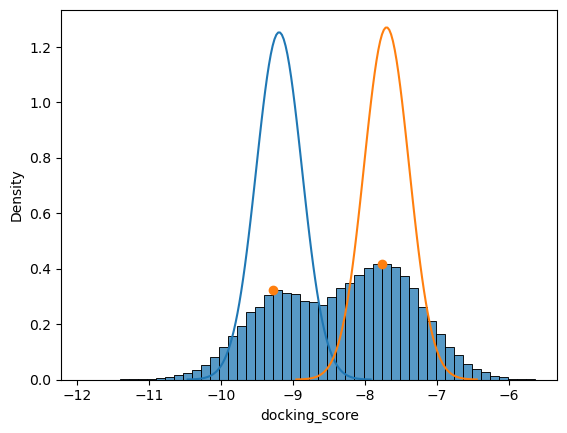

In [21]:
from scipy.stats import norm

ax = sns.histplot(dock_df, x="docking_score", bins=50, stat="density")
plt.scatter(bins[maxima], counts[maxima])

for mu, sigma in zip(gm.means_.flatten(), gm.covariances_.flatten()):
    x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 100)
    ax.plot(x, norm.pdf(x, mu, sigma))

In [36]:
df["mols"] = df["smiles"].map(Chem.MolFromSmiles)
df["class"] = gm.predict(df["docking_score"].values.reshape(-1, 1))

In [ ]:
from IPython import display

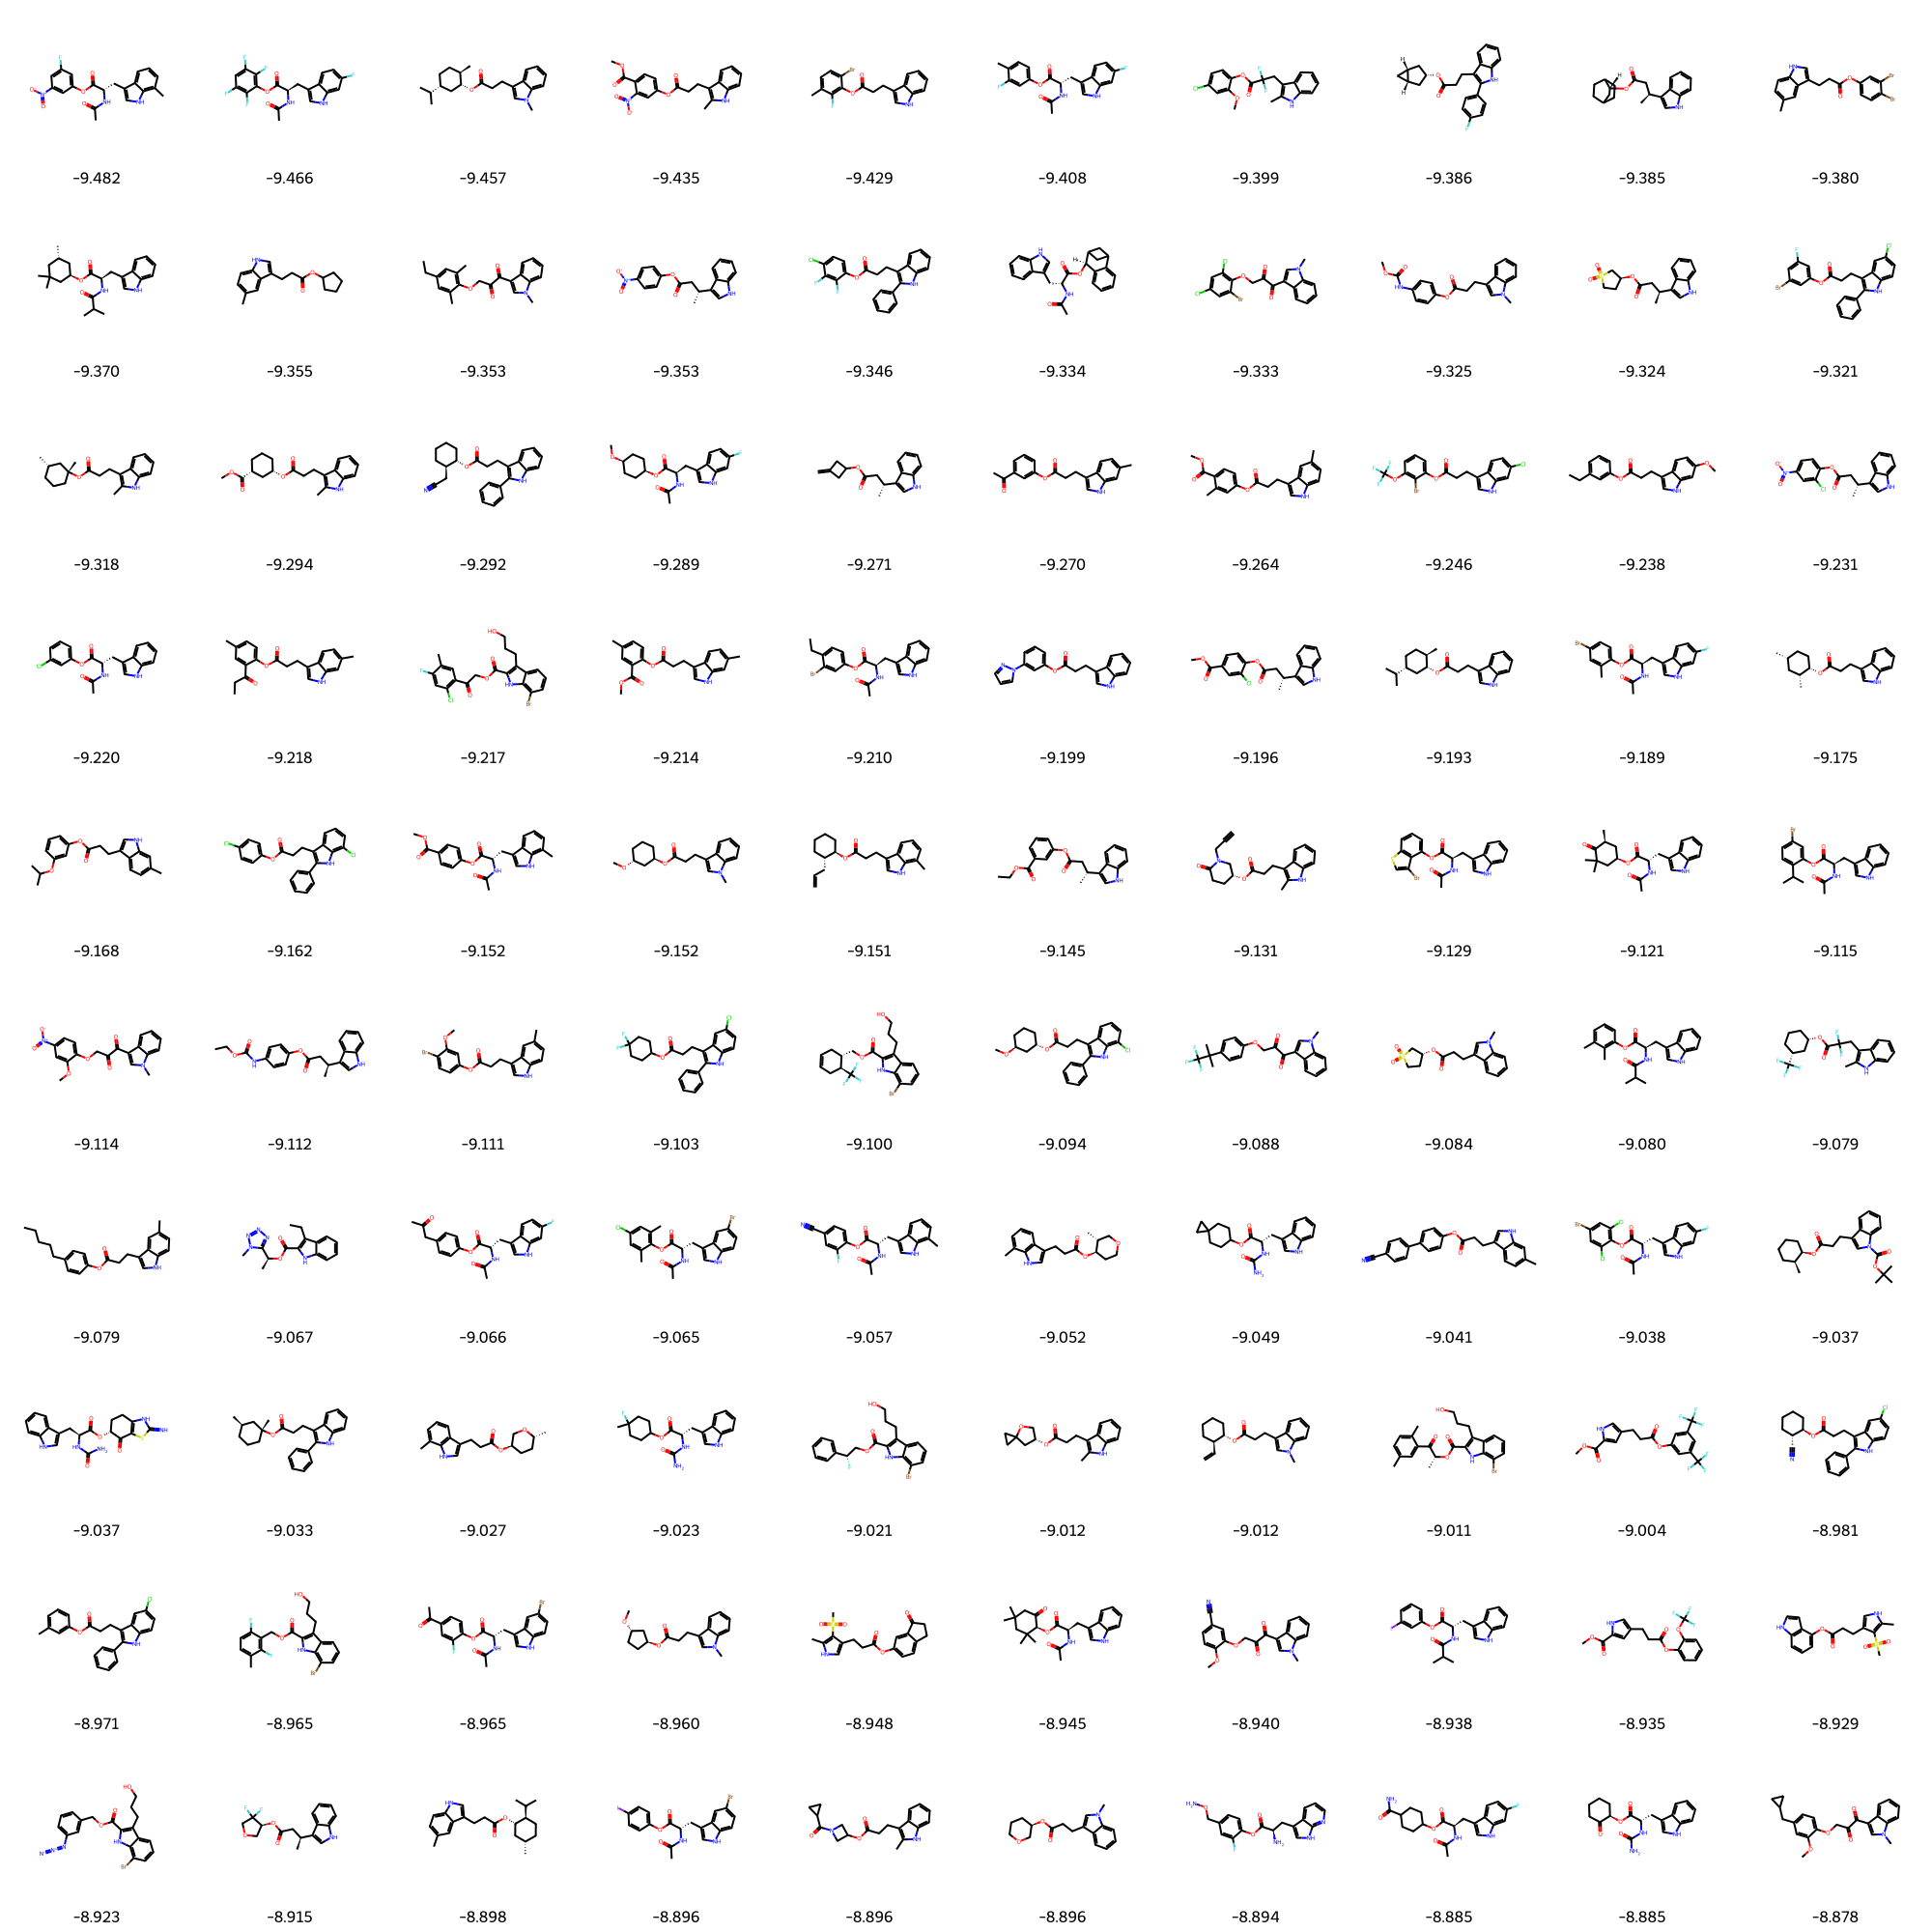

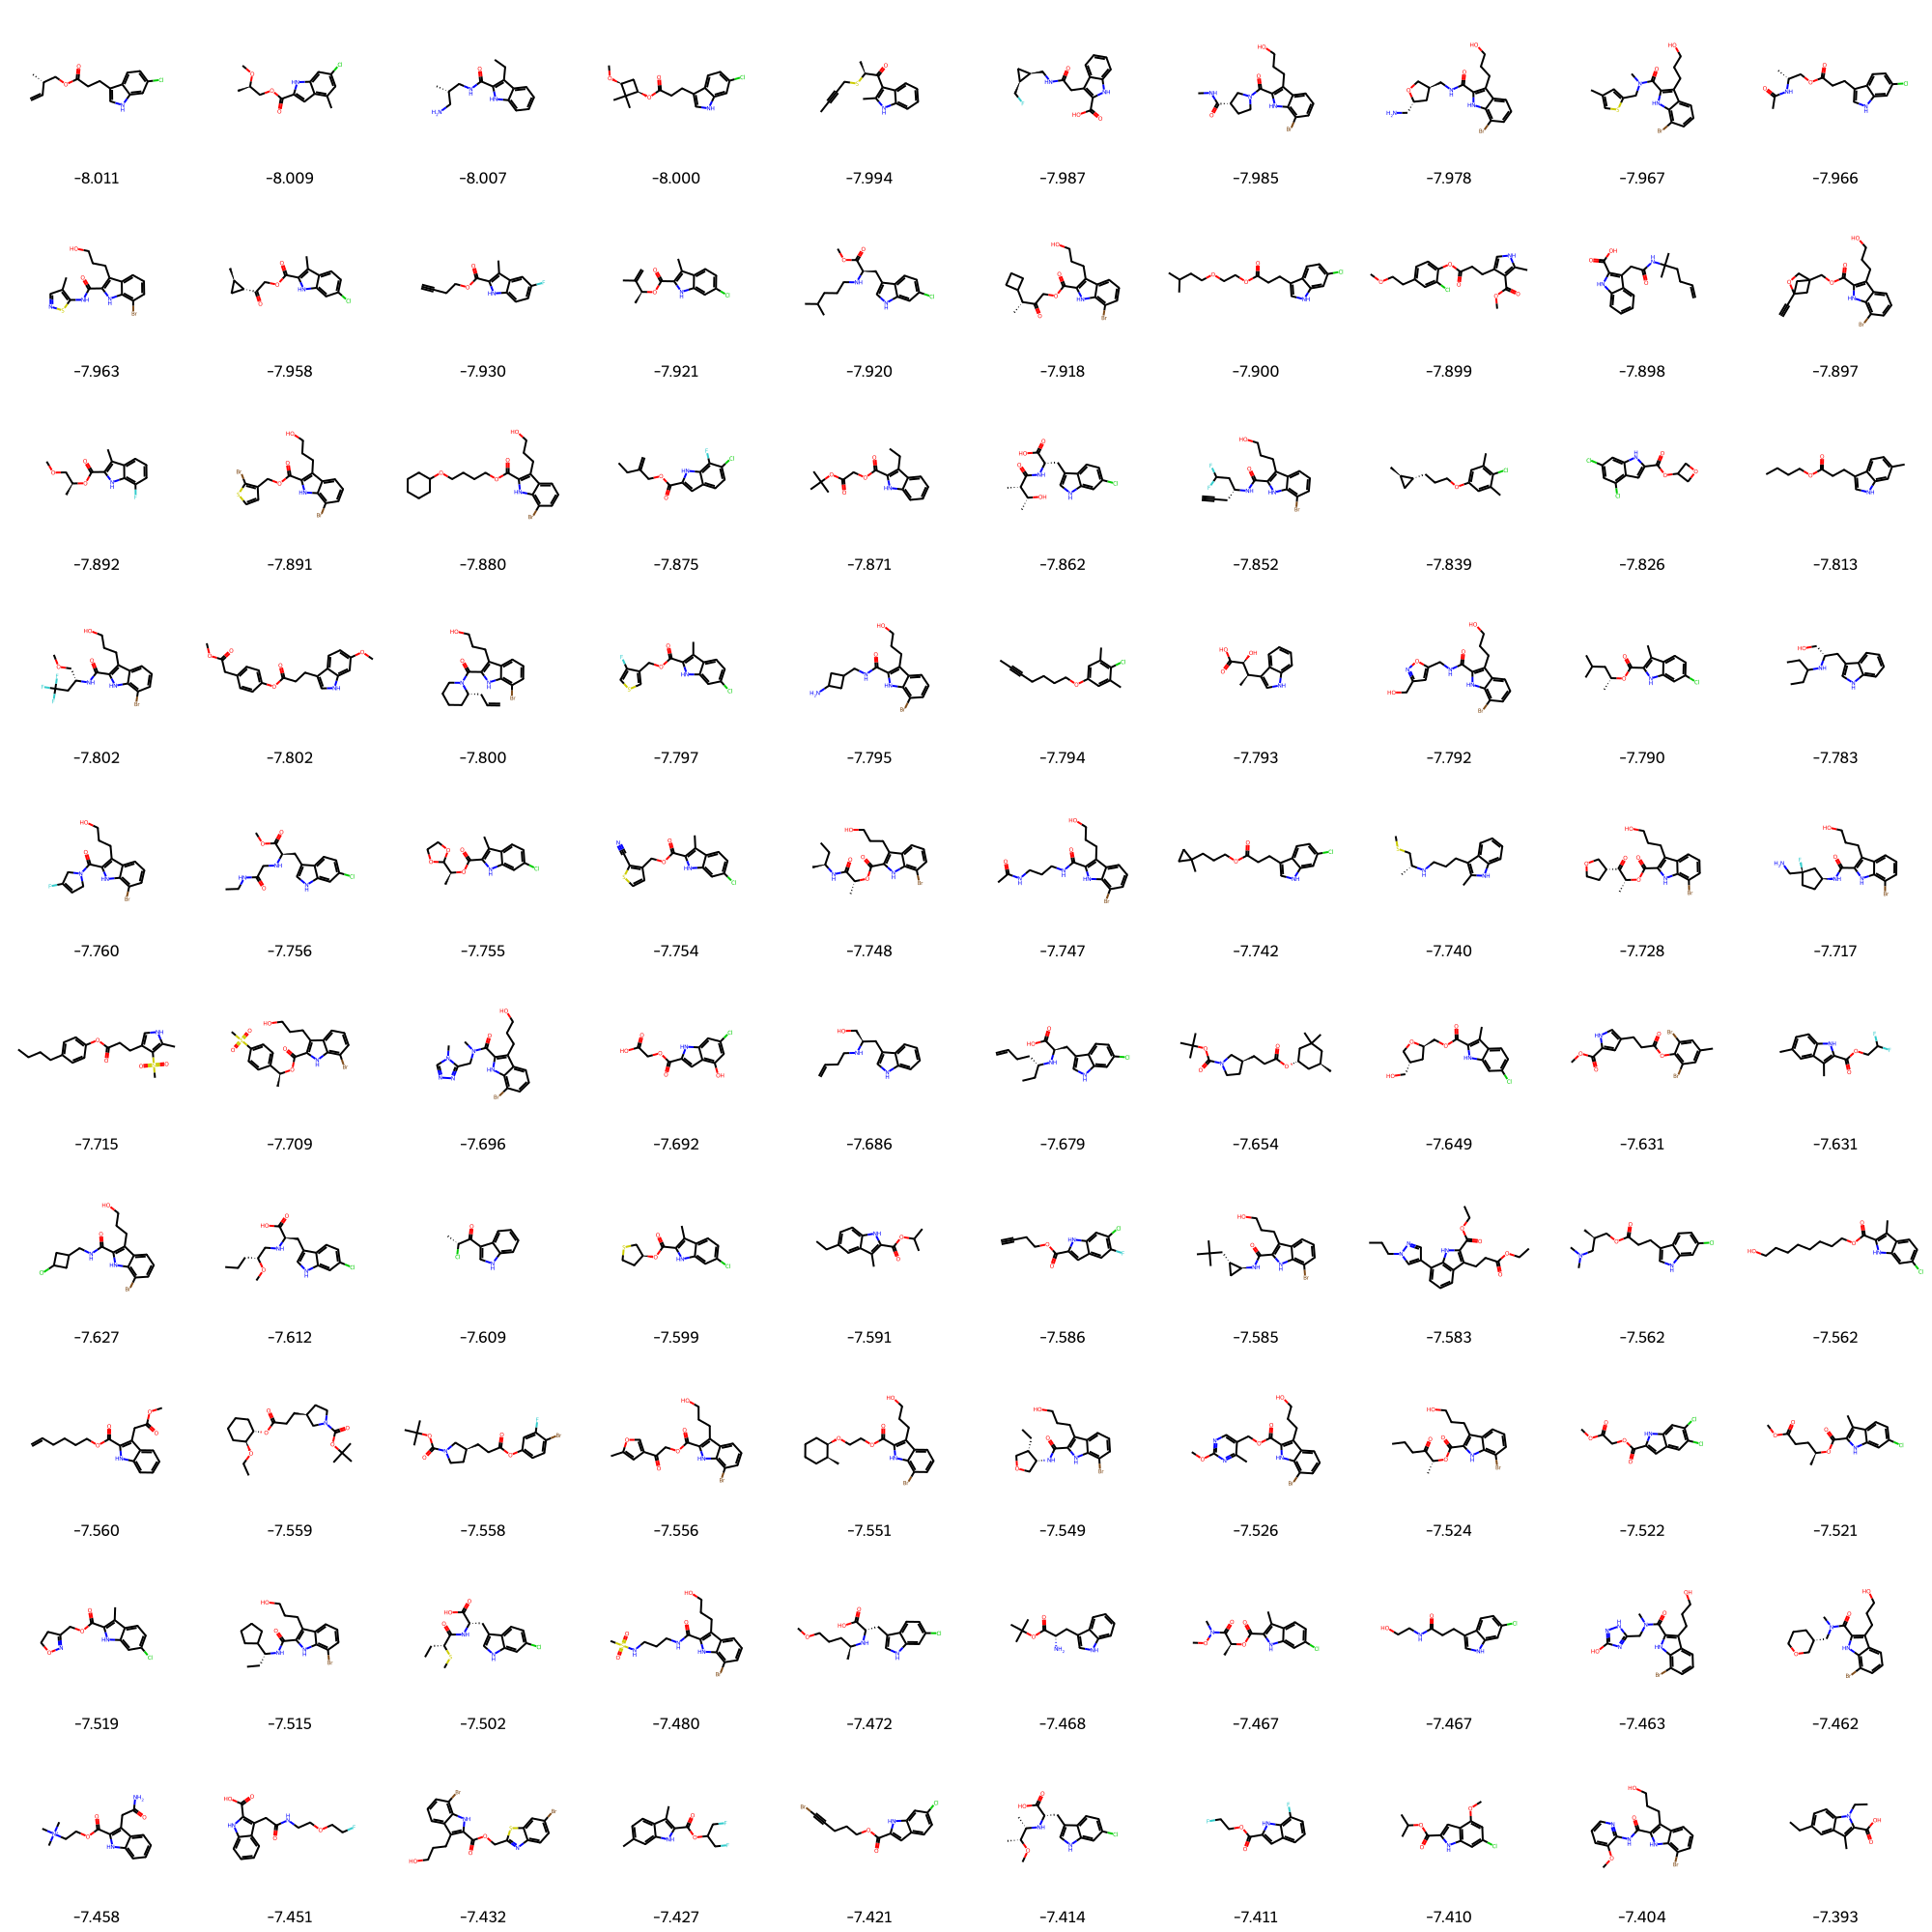

In [73]:
images = []
for c, (mu, sigma) in enumerate(zip(gm.means_.flatten(), gm.covariances_.flatten())):
    lo, up = mu - sigma, mu + sigma
    close = df[
        (df["class"] == c) & (lo <= df["docking_score"]) & (df["docking_score"] <= up)
    ]
    sample = close.sample(100).sort_values(by="docking_score")
    display(
        Draw.MolsToGridImage(
            sample["mols"],
            molsPerRow=10,
            legends=sample["docking_score"].apply(lambda x: f"{x:.3f}").tolist(),
            maxMols=100,
        )
    )

In [75]:
# Let's calculate fingerprints and embed into 2 dimensions.
from sklearn.decomposition import PCA
from rdkit.Chem import rdFingerprintGenerator

generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
fps = df["mols"].map(generator.GetFingerprintAsNumPy)
fps = np.vstack(fps.values)

In [95]:
pca = PCA(n_components=2)
embeddings = pca.fit_transform(fps)

<Axes: >

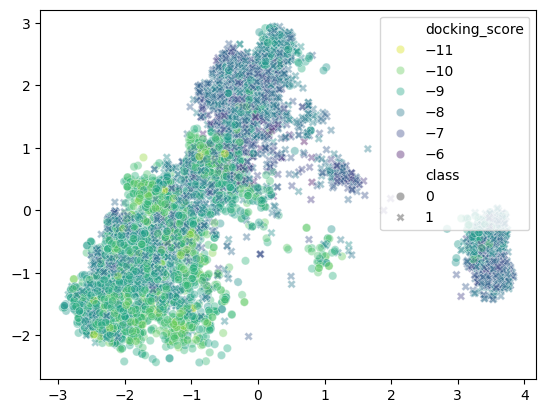

In [103]:
rng = np.random.default_rng(0)
sample = rng.choice(len(embeddings), 10_000)

df_sample = df.iloc[sample]

sns.scatterplot(
    df_sample,
    x=embeddings[sample, 0],
    y=embeddings[sample, 1],
    hue=df_sample["docking_score"],
    style=df_sample["class"],
    palette="viridis_r",
    alpha=0.4,
)

We see two clear clusters, although they don't seem to be related to the docking score